Practical HW 1
Machine Learning 2
April 13 2026
Amanda Boschman

# Practical Homework 1: Decision Trees

This notebook uses decision trees to explore youth substance use from the dataset called NSDUH (National Survey on Drug Use and Health).

The goal of this notebook is to utilize binary, multi-class, and regression classification, as well as decision tree ensemble methods, to explore the relationships between youth experiences and demographics.

# Research Question:

How well can youth demographics, family life, and experiences predict alcohol usage in a month period, whether the youth has ever used marijuana, and cigarette usage frequency?

# Data description

From the NSDUH dataset, the youth data was selected (responses from ages under 18). Variables included substance use frequency, youth experiences (e.g. percieved peer disapproval, grade average, frequency of parents checking their homework), and demographics (e.g. income level, race, sex).

The following target outcomes and predictors were chosen, keeping in mind what predictors were likely the same information in another metric or too closely correlated (e.g. ever used alcohol and alcohol frequency in the past year).

Target Outcomes:
1. Binary Classification: MRJFLAG (ever used marijuana)
2. Multi-Class Classification: ALCMDAYS (# of days used alcohol in past month)
3. Regression Classification: IRCIGFM (cigarette frequency in past month)


Predictors:
- IFATHER (categorical): whether the youth's father is in the household or not

- POVERTY3 (categorical): whether the youth is living in poverty, up to two times the federal poverty level, or more than two times the federal poverty level.

- IRSEX (binary): whether the youth is male or female

- NEWRACE2 (categorical): the youth's race/ethnicity (7 possible categories)

- PRCHORE2 (binary): how often the youth's parents make them do chores around the house in the past year

- PRLMTTV2 (binary): how often the youth's parents limit their amount of TV in the past year

- PARCHKHW (binary): how often the youth's parents check if their homework is completed in the past year

- YFLTMRJ2 (binary): how the youth feels about their peers trying marijuana

- RLGATTD (binary): number of times the youth has attended religious services in the past year

- AVGGRADE (binary): the youth's grade average for the last grading period completed


Imports:

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import precision_score, classification_report, mean_squared_error, r2_score, recall_score, f1_score, confusion_matrix, accuracy_score
from sklearn.inspection import PartialDependenceDisplay

Load Data

In [2]:
youth_data = pd.read_csv('/Users/amandaboschman/Desktop/ML2 Spring 2026/youth_data.csv')

Explore Data

In [3]:
youth_data.head()

,IRALCFY,IRMJFY,IRCIGFM,IRSMKLSS30N,IRALCFM,IRMJFM,IRCIGAGE,IRSMKLSSTRY,IRALCAGE,IRMJAGE,...,EDUSCHLGO,EDUSCHGRD2,EDUSKPCOM,IMOTHER,IFATHER,INCOME,GOVTPROG,POVERTY3,PDEN10,COUTYP4
0,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,3,0,1,1,2,2,1,2,2
1,991,60,91.0,91,91.0,2.0,991,991,991,14,...,1,6,0,1,1,2,2,1,2,2
2,1,991,91.0,91,93.0,91.0,991,991,11,991,...,1,2,1,1,1,4,2,3,1,1
3,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,2,0,1,1,3,2,2,1,1
4,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,5,0,1,1,4,2,3,2,2


In [4]:
youth_data.columns

Index(['IRALCFY', 'IRMJFY', 'IRCIGFM', 'IRSMKLSS30N', 'IRALCFM', 'IRMJFM',
       'IRCIGAGE', 'IRSMKLSSTRY', 'IRALCAGE', 'IRMJAGE', 'MRJFLAG', 'ALCFLAG',
       'TOBFLAG', 'ALCYDAYS', 'MRJYDAYS', 'ALCMDAYS', 'MRJMDAYS', 'CIGMDAYS',
       'SMKLSMDAYS', 'SCHFELT', 'TCHGJOB', 'AVGGRADE', 'STNDSCIG', 'STNDSMJ',
       'STNDALC', 'STNDDNK', 'PARCHKHW', 'PARHLPHW', 'PRCHORE2', 'PRLMTTV2',
       'PARLMTSN', 'PRGDJOB2', 'PRPROUD2', 'ARGUPAR', 'YOFIGHT2', 'YOGRPFT2',
       'YOHGUN2', 'YOSELL2', 'YOSTOLE2', 'YOATTAK2', 'PRPKCIG2', 'PRMJEVR2',
       'PRMJMO', 'PRALDLY2', 'YFLPKCG2', 'YFLTMRJ2', 'YFLMJMO', 'YFLADLY2',
       'FRDPCIG2', 'FRDMEVR2', 'FRDMJMON', 'FRDADLY2', 'TALKPROB', 'PRTALK3',
       'PRBSOLV2', 'PREVIOL2', 'PRVDRGO2', 'GRPCNSL2', 'PREGPGM2', 'YTHACT2',
       'DRPRVME3', 'ANYEDUC3', 'RLGATTD', 'RLGIMPT', 'RLGDCSN', 'RLGFRND',
       'IRSEX', 'NEWRACE2', 'HEALTH2', 'EDUSCHLGO', 'EDUSCHGRD2', 'EDUSKPCOM',
       'IMOTHER', 'IFATHER', 'INCOME', 'GOVTPROG', 'POVERTY3', 'PDEN10',

In [5]:
youth_data.shape

(10561, 79)

Selected Target Variables

In [6]:
bin_target = 'MRJFLAG'

multi_target = 'ALCMDAYS'

reg_target = 'IRCIGFM'

Selected Predictor Variables

In [7]:
predictors = ['IFATHER', 'POVERTY3', 'IRSEX', 'NEWRACE2', 'PRCHORE2', 'PRLMTTV2', 'PARCHKHW', 'YFLTMRJ2', 'RLGATTD', 'AVGGRADE']

In [8]:
#Viewing how many unique values each predictor has
youth_data.nunique()[predictors]

IFATHER     3
POVERTY3    3
IRSEX       2
NEWRACE2    7
PRCHORE2    2
PRLMTTV2    2
PARCHKHW    2
YFLTMRJ2    2
RLGATTD     2
AVGGRADE    2
dtype: int64

In [9]:
#Viewing the unique values for each predictor
for col in predictors:
    print(f'{col}')
    print(youth_data[col].unique())

IFATHER
[1 2 3]
POVERTY3
[1 3 2]
IRSEX
[1 2]
NEWRACE2
[7 1 6 4 2 5 3]
PRCHORE2
[ 1.  2. nan]
PRLMTTV2
[ 2.  1. nan]
PARCHKHW
[ 1.  2. nan]
YFLTMRJ2
[ 1.  2. nan]
RLGATTD
[ 2.  1. nan]
AVGGRADE
[ 2. nan  1.]


Data Cleaning & Preparation

Create DataFrame of Selected Predictors & Target Outcomes

In [10]:
selected_cols = predictors + [bin_target] + [multi_target] + [reg_target]

df = youth_data[selected_cols]

df.head()

,IFATHER,POVERTY3,IRSEX,NEWRACE2,PRCHORE2,PRLMTTV2,PARCHKHW,YFLTMRJ2,RLGATTD,AVGGRADE,MRJFLAG,ALCMDAYS,IRCIGFM
0,1,1,1,7,1.0,2.0,1.0,1.0,2.0,2.0,0,5,91.0
1,1,1,2,1,2.0,2.0,1.0,1.0,2.0,2.0,1,5,91.0
2,1,3,1,6,1.0,1.0,1.0,1.0,2.0,2.0,0,5,91.0
3,1,2,2,7,2.0,2.0,1.0,1.0,2.0,NaN,0,5,91.0
4,1,3,1,1,1.0,2.0,2.0,1.0,2.0,2.0,0,5,91.0


In [11]:
df.shape

(10561, 13)

Coded Responses that behave like missing/unknown values: 'IFATHER'.

A '3' response means that the youth does not know whether their father is in the household.
First, let's check how many
3 responses are in 'IFATHER'.

In [12]:
#How many 3's in IFATHER?

(df['IFATHER'] == 3).sum()

np.int64(73)

Since there are only 73 rows that have a response of '3' for 'IFATHER' in the dataset of 10,561 rows, let's remove those 73 rows. This simplifies our model by turning the predictor variable 'IFATHER' into a binary variable instead of categorical. To clarify, a value of '1' indicates the youth's father is in the household and a value of '2' indicates the youth's father is not in the household.

In [13]:
df = df[df['IFATHER'] != 3]

Checking for NaNs/Missing Data

In [14]:
df.isna().sum()

IFATHER       0
POVERTY3      0
IRSEX         0
NEWRACE2      0
PRCHORE2     33
PRLMTTV2     65
PARCHKHW     75
YFLTMRJ2     87
RLGATTD     284
AVGGRADE    708
MRJFLAG       0
ALCMDAYS      0
IRCIGFM       0
dtype: int64

If it is less than 100 rows (approximately less than 1% of the dataset), delete the NaN rows. If it is more than 100 rows (approximately more than 1% of the dataset), impute the NaN values with the mode of the column.

Delete rows with NaNs in these columns:
PRCHORE2
PRLMTTV2
PARCHKHW
YFLTMRJ2

Rows with NaNs in these columns, fill in NaNs with mode of the column:
RLGATTD
AVGGRADE

In [15]:
#Delete some Nans
rows_nan_delete = ['PRCHORE2', 'PRLMTTV2', 'PARCHKHW', 'YFLTMRJ2']

df = df.dropna(subset=rows_nan_delete)

In [16]:
#Impute Mode
rows_mode_impute = ['RLGATTD', 'AVGGRADE']

for col in rows_mode_impute:
    df[col] = df[col].fillna(df[col].mode()[0])

Verifying Cleaning is Complete

In [17]:
#Verifying all NaNs are deleted/imputed
df.isna().sum()

IFATHER     0
POVERTY3    0
IRSEX       0
NEWRACE2    0
PRCHORE2    0
PRLMTTV2    0
PARCHKHW    0
YFLTMRJ2    0
RLGATTD     0
AVGGRADE    0
MRJFLAG     0
ALCMDAYS    0
IRCIGFM     0
dtype: int64

In [18]:
#Shape before cleaning was (10561, 13)
df.shape

(10296, 13)

In [19]:
#Unique values in IFATHER
#Verifying 3's were removed
df['IFATHER'].unique()

array([1, 2])

After cleaning, no missing values remain in df. And, IFATHER responses are now limited to only 1's and 2's (3's were removed).

Reset the index since dropping rows leads to a nonconsecutive incomplete index.

In [20]:
#Index right now
df.index

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       10550, 10551, 10552, 10553, 10554, 10556, 10557, 10558, 10559, 10560],
      dtype='int64', length=10296)

In [21]:
#Reset the index
df = df.reset_index(drop=True)

In [22]:
#Verify the index is consecutive and complete
df.index

RangeIndex(start=0, stop=10296, step=1)

Cleaned Dataset

In [23]:
df.head()

,IFATHER,POVERTY3,IRSEX,NEWRACE2,PRCHORE2,PRLMTTV2,PARCHKHW,YFLTMRJ2,RLGATTD,AVGGRADE,MRJFLAG,ALCMDAYS,IRCIGFM
0,1,1,1,7,1.0,2.0,1.0,1.0,2.0,2.0,0,5,91.0
1,1,1,2,1,2.0,2.0,1.0,1.0,2.0,2.0,1,5,91.0
2,1,3,1,6,1.0,1.0,1.0,1.0,2.0,2.0,0,5,91.0
3,1,2,2,7,2.0,2.0,1.0,1.0,2.0,2.0,0,5,91.0
4,1,3,1,1,1.0,2.0,2.0,1.0,2.0,2.0,0,5,91.0


In [24]:
df.shape

(10296, 13)

In [25]:
df.dtypes

IFATHER       int64
POVERTY3      int64
IRSEX         int64
NEWRACE2      int64
PRCHORE2    float64
PRLMTTV2    float64
PARCHKHW    float64
YFLTMRJ2    float64
RLGATTD     float64
AVGGRADE    float64
MRJFLAG       int64
ALCMDAYS      int64
IRCIGFM     float64
dtype: object

Next, the predictors need to be put into a model-ready format via one-hot encoding and label binarizer.

# Encoding Predictors

Exploring which predictors to one-hot encode (OH) and which to bin (LB).

LabelBinarizer is used for binary predictors.

OneHotEncoder is used for predictors with more than 3 categories that do not have a real order.

Predictors:
- IFATHER (binary) -> LB
- POVERTY3 (categorical) -> OH
- IRSEX (binary) -> LB
- NEWRACE2 (categorical) -> OH
- PRCHORE2 (binary) -> LB
- PRLMTTV2 (binary) -> LB
- PARCHKHW (binary) -> LB
- YFFLTMRJ2 (binary) -> LB
- RLGATTD (binary) -> LB
- AVGGRADE (binary) -> LB

In [26]:
#LabelBinarizer for some columns
cols_to_bin = ['IFATHER', 'IRSEX', 'PRCHORE2', 'PRLMTTV2', 'PARCHKHW', 'YFLTMRJ2', 'RLGATTD', 'AVGGRADE']

lb = LabelBinarizer()

for col in cols_to_bin:
    df[col] = lb.fit_transform(df[col])

In [27]:
#One-Hot Encoding
cols_to_oh = ['POVERTY3', 'NEWRACE2']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_array = encoder.fit_transform(df[cols_to_oh])

#turn back into DataFrame
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(cols_to_oh),
    index=df.index
)

#sparse_output=False prevents memory efficient storage
#that prevents easy conversion back into a dataframe

#index=df.index sets the index of the encoded_df
#to be the same as it was in the current df
#This allows for concatenation below to have the rows line up correctly

In [28]:
#Drop the original columns that have now been OH
df = df.drop(columns=cols_to_oh)

In [29]:
#Concatenate the encoded dataframe with the remaining columns
df = pd.concat([df, encoded_df], axis=1)

In [30]:
#Verifying the index remains unchanged
df.index

RangeIndex(start=0, stop=10296, step=1)

Exploring the final cleaned dataset (df)

In [31]:
df.head()

,IFATHER,IRSEX,PRCHORE2,PRLMTTV2,PARCHKHW,YFLTMRJ2,RLGATTD,AVGGRADE,MRJFLAG,ALCMDAYS,...,POVERTY3_1,POVERTY3_2,POVERTY3_3,NEWRACE2_1,NEWRACE2_2,NEWRACE2_3,NEWRACE2_4,NEWRACE2_5,NEWRACE2_6,NEWRACE2_7
0,0,0,0,1,0,0,1,1,0,5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,1,1,1,0,0,1,1,1,5,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,1,1,0,5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,1,1,1,0,0,1,1,0,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0,0,1,1,0,1,1,0,5,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
df.shape

(10296, 21)

In [33]:
df.isna().sum()

IFATHER       0
IRSEX         0
PRCHORE2      0
PRLMTTV2      0
PARCHKHW      0
YFLTMRJ2      0
RLGATTD       0
AVGGRADE      0
MRJFLAG       0
ALCMDAYS      0
IRCIGFM       0
POVERTY3_1    0
POVERTY3_2    0
POVERTY3_3    0
NEWRACE2_1    0
NEWRACE2_2    0
NEWRACE2_3    0
NEWRACE2_4    0
NEWRACE2_5    0
NEWRACE2_6    0
NEWRACE2_7    0
dtype: int64

In [34]:
columns_cleaned = df.columns
predictors_cleaned = df.columns.drop([bin_target, multi_target, reg_target])

## Modeling Overview

Three model types will be explored: binary classification, multi-class classification, and regression classification.

For each classification type, a baseline decision tree is fitted first. Then, hyperparameters are tuned using cross-validation. After that, the basic trees are compared to ensemble tree methods.

Binary Classification Model

First, the baseline binary classification model:

In [35]:
#Splitting df into predictors & target
X = df[predictors_cleaned]

y_bin = df[bin_target]

In [36]:
#Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y_bin,
                                                    train_size=0.8, test_size=0.2,
                                                    random_state=2, stratify=y_bin)

#stratify=y_bin helps preserve the proportions of the data

In [37]:
#Utilized later
X_train_bin, X_test_bin, y_train_bin, y_test_bin = X_train, X_test, y_train, y_test

In [38]:
#Fit decision tree model
tree_binary = DecisionTreeClassifier()
tree_binary.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [39]:
#Predict on test data
tree_binary_pred = tree_binary.predict(X_test)

In [40]:
#Create confusion matrix
confusion_matrix_bin = pd.crosstab(index=y_test, columns=tree_binary_pred,
                               rownames=['Actual'], colnames=['Predicted'])
print(confusion_matrix_bin)

Predicted     0   1
Actual             
0          1660  89
1           230  81


In [41]:
#Calculate the accuracy of the decision tree on the test data
binary_accuracy = tree_binary.score(X_test, y_test)
print('Accuracy: {:.2f}%'.format(binary_accuracy*100))

Accuracy: 84.51%


In [42]:
#Calculate precision
binary_precision = precision_score(y_test, tree_binary_pred)
print('Precision: {:.2f}%'.format(binary_precision*100))

Precision: 47.65%


In [43]:
#Calculate recall
binary_recall = recall_score(y_test, tree_binary_pred, zero_division=0)
print('Recall: {:.2f}%'.format(binary_recall*100))

Recall: 26.05%


In [44]:
#Calculate f1 score
binary_f1 = f1_score(y_test, tree_binary_pred, zero_division=0)
print('F1 score: {:.2f}%'.format(binary_f1*100))

F1 score: 33.68%


The basline binary classification tree is a starting point. Accuracy was calculated, but is often misleading since class imbalance often makes accuracy look stronger than in reality. To account for that issue, precision, recall, and F1 score were also calculated, which better measure how well the model identifies the positive class.

## Binary Classification: Cross-Validation and Tuning

Decision trees are sensitive to hyperparameters such as pruning strength, depth, and leaf size. Cross-validation is used to avoid overfitting.

In [45]:
#Pruning path
ccp_path = tree_binary.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = ccp_path.ccp_alphas

In [46]:
#Build the parameter grid
param_grid = {'ccp_alpha': ccp_alphas}

In [47]:
#Run grid search
grid_binary = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=91),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=2
)

grid_binary.fit(X_train, y_train)

/Users/amandaboschman/DATA ML 2/.conda/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
10 fits failed out of a total of 2435.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/amandaboschman/DATA ML 2/.conda/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/amandaboschman/DATA ML 2/.conda/lib/python3.12/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
  File "/Users/amandaboschman/DATA ML 2/.conda/lib/python3.12/site-packages/sklearn/base.py", line 492, in _va

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=91)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ccp_alpha': array([ 0.000...27039325e-02])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and ca

In [48]:
best_ccp_alpha = grid_binary.best_params_['ccp_alpha']
best_cv_score = grid_binary.best_score_

print(f'Best ccp_alpha: {best_ccp_alpha: .6f}')
print(f'Best CV F1: {best_cv_score: .5f}')

Best ccp_alpha:  0.000010
Best CV F1:  0.33065


In [49]:
best_binary_tree = grid_binary.best_estimator_
binary_pred_tuned = best_binary_tree.predict(X_test)

## Tuned Binary Classification Model Evaluation

Cross-validation allowed the best hyperparameters to be selected. Then, the tuned model is evaluated on the test set. Next, the tuned model's confusion matrix and evaluation metrics are compared to the baseline model's.

In [50]:
#Create confusion matrix
confusion_matrix_bin_pruned = pd.crosstab(index=y_test, columns=binary_pred_tuned,
                               rownames=['Actual'], colnames=['Predicted'])
print(confusion_matrix_bin_pruned)

Predicted     0   1
Actual             
0          1654  95
1           231  80


In [51]:
#Calculate the accuracy of the decision tree on the test data
binary_accuracy_pruned = best_binary_tree.score(X_test, y_test)
print('Accuracy: {:.2f}%'.format(binary_accuracy_pruned*100))

Accuracy: 84.17%


In [52]:
#Calculate precision
binary_precision_pruned = precision_score(y_test, binary_pred_tuned, zero_division=0)
print('Precision: {:.2f}%'.format(binary_precision_pruned*100))

Precision: 45.71%


In [53]:
#Calculate recall
binary_recall_pruned = recall_score(y_test, binary_pred_tuned, zero_division=0)
print('Recall: {:.2f}%'.format(binary_recall_pruned*100))

Recall: 25.72%


In [54]:
#Calculate f1
binary_f1_pruned = f1_score(y_test, binary_pred_tuned, zero_division=0)
print('f1 score: {:.2f}%'.format(binary_f1_pruned*100))

f1 score: 32.92%


# Binary Baseline vs. Pruned

For binary classification, pruning slightly reduced accuracy, precision, recall, and f1 score.

Multi-Class Classification Model

First, the baseline multi-class classification model:

In [55]:
#Splitting df into predictors & target
X = df[predictors_cleaned]

y_multi = df[multi_target]

In [56]:
#Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y_multi,
                                                    train_size=0.8, test_size=0.2,
                                                    random_state=42, stratify=y_multi)

In [57]:
#To be utilized later in ensemble methods
X_train_multi, X_test_multi, y_train_multi, y_test_multi = X_train, X_test, y_train, y_test

In [58]:
#Fit decision tree model
tree_multi = DecisionTreeClassifier()
tree_multi.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [59]:
#Predict on test data
tree_multi_pred = tree_multi.predict(X_test)

In [60]:
#Create confusion matrix
confusion_matrix_multi = pd.crosstab(index=y_test, columns=tree_multi_pred,
                               rownames=['Actual'], colnames=['Predicted'])
print(confusion_matrix_multi)

Predicted   1  2  3  4     5
Actual                      
1           5  2  0  0    83
2           4  2  0  0    33
3           0  0  0  0    14
4           0  0  0  0     2
5          31  6  3  1  1874


In [61]:
#Calculate the accuracy of the decision tree on the test data
multi_accuracy = tree_multi.score(X_test, y_test)
print('Accuracy: {:.2f}%'.format(multi_accuracy*100))

Accuracy: 91.31%


In [62]:
#Calculate classification report
multi_class_report = classification_report(y_test, tree_multi_pred)
print('Classification Report:', multi_class_report)

Classification Report:               precision    recall  f1-score   support

           1       0.12      0.06      0.08        90
           2       0.20      0.05      0.08        39
           3       0.00      0.00      0.00        14
           4       0.00      0.00      0.00         2
           5       0.93      0.98      0.96      1915

    accuracy                           0.91      2060
   macro avg       0.25      0.22      0.22      2060
weighted avg       0.88      0.91      0.89      2060



The baseline multi-class classification model is also just that, a baseline. Class imbalance is an issue here, also. To combat that, evaluation relies on the confusion matrix, per-class performance, and maco-averaged metrics.

## Multi-Class Classification: Cross-Validation and Tuning

The multi-class decision tree is tuned using cross-validation. Tuning reduces the likelihood of overly complex trees that overfit the training data. Tuning allows for trees that are better at generalizing.

In [63]:
#Extract cost complexity pruning path
ccp_path_multi = tree_multi.cost_complexity_pruning_path(X_train, y_train)

In [64]:
#Create a parameter grid using the pruning path
param_grid_multi = {
    'ccp_alpha': ccp_path_multi.ccp_alphas
}

In [65]:
#Grid Search with Cross-Validation
grid_multi = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=89),
    param_grid=param_grid_multi,
    cv=5,
    scoring='accuracy',
    n_jobs=2
)

In [66]:
#Fit on training data
grid_multi.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=89)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ccp_alpha': array([0.0000...50901677e-03])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold 

In [67]:
best_multi_alpha = grid_multi.best_params_['ccp_alpha']
best_multi_score = grid_multi.best_score_

print(f'Best ccp_alpha: {best_multi_alpha: .6f}')
print(f'Best CV accuracy: {best_multi_score: .5f}')

Best ccp_alpha:  0.000573
Best CV accuracy:  0.92994


In [68]:
best_multi_tree = grid_multi.best_estimator_

In [69]:
#Predict on test data
multi_pred_tuned = best_multi_tree.predict(X_test)

## Tuned Multi-Class Classification Model Evaluation

Performance of the tuned multi-class tree is evaluated using the confusion matrix and classification report. Predicting minority classes accurately is important but not represented obviously in the overall accuracy metric.

In [70]:
#Create confusion matrix
confusion_matrix_multi_tuned = pd.crosstab(index=y_test, columns=multi_pred_tuned,
                               rownames=['Actual'], colnames=['Predicted'])
print(confusion_matrix_multi_tuned)

Predicted     5
Actual         
1            90
2            39
3            14
4             2
5          1915


# Multi-class Baseline vs. Pruned

For multi-class classification,both the baseline and the pruned model struggled with minority classes. The confusion matrices and classification reports show that the models heavily predict the dominant class and fail to correctly identify multiple classes. This is indicative of significant class imbalance.

## Regression Model

Before creating the regression model, the regression target variable (IRCIGFM) must be cleaned. Before cleaning, IRCIGFM allows for responses to be integers 1-30 (representing the frequency of cigarette use in the past month), 91 (representing never used cigarettes), and 93 (did not use cigarettes in the past month).

To clean, all responses of 91 and 93 will be replaced with 0, indicating no cigarette use in the past month. This does remove the differentiation between youths you have never used cigarattes and those who have used cigarettes but not within the past month. Since the target variable was chosen with the intention of predicting frequency of cigarette usage in the past month, this simplification was made.

In [71]:
df['IRCIGFM'] = df['IRCIGFM'].replace({91:0, 93:0})

First, the baseline regression classification model:

In [72]:
#Splitting df into predictors & target
X = df[predictors_cleaned]

y_reg = df[reg_target]

In [73]:
#Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y_reg,
                                                    train_size=0.8, test_size=0.2,
                                                    random_state=98)

In [74]:
#To be utilized later in ensemble methods
X_train_reg, X_test_reg, y_train_reg, y_test_reg = X_train, X_test, y_train, y_test

In [75]:
#Fit decision tree model
tree_reg = DecisionTreeRegressor(max_leaf_nodes=10, random_state=1)
tree_reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

In [76]:
#Predict on test data
tree_reg_pred = tree_reg.predict(X_test)

In [77]:
#Calculate the MSE (Mean Squared Error)
reg_mse = mean_squared_error(y_test, tree_reg_pred)

print('MSE: {:.5f}'.format(reg_mse))

MSE: 1.35646


In [78]:
#Calculate the RSS (Resiudal Sum of Squares)
reg_rss = ((y_test - tree_reg_pred)**2).sum()

print('RSS: {:.5f}'.format(reg_rss))

RSS: 2794.29894


In [79]:
#Calculate R-squared
reg_r2 = r2_score(y_test, tree_reg_pred)

print('R-squared: {:.5f}'.format(reg_r2))

R-squared: 0.01125


The baseline regression classification model is evaluated using mean square error, residual sum of squares, and R-squared, which is most appropriate for numeric variables.

## Regression: Cross-Validation and Tuning

In [80]:
#Extract cost-complexity pruning path
ccp_path_reg = tree_reg.cost_complexity_pruning_path(X_train, y_train)

In [81]:
#Parameter grid using pruning path
param_grid_reg = {
    'ccp_alpha': np.unique(ccp_path_reg.ccp_alphas)
}

In [82]:
#Grid search with cross validation
grid_reg = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=40),
    param_grid=param_grid_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=2
)

In [83]:
#Fit on the training data
grid_reg.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=40)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': array([0. ..., 0.01720846])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [84]:
#Best results
best_reg_alpha = grid_reg.best_params_['ccp_alpha']
best_reg_score = grid_reg.best_score_

print(f'Best ccp_alpha: {best_reg_alpha: .6f}')
print(f'Best CV neg-MSE: {best_reg_score: .5f}')

Best ccp_alpha:  0.017208
Best CV neg-MSE: -1.26739


In [85]:
#Best pruned model
best_reg_tree = grid_reg.best_estimator_

In [86]:
#Predict on test data
reg_pred_tuned = best_reg_tree.predict(X_test)

## Tuned Regression Classification Model Evaluation

In [87]:
#Calculate the MSE (Mean Squared Error)
reg_mse_tuned = mean_squared_error(y_test, reg_pred_tuned)

print('Pruned MSE: {:.5f}'.format(reg_mse_tuned))

Pruned MSE: 1.37191


In [88]:
#Calculate the RSS (Resiudal Sum of Squares)
reg_rss_tuned = ((y_test - reg_pred_tuned)**2).sum()

print('Pruned RSS: {:.5f}'.format(reg_rss_tuned))

Pruned RSS: 2826.13009


In [89]:
#Calculate R-squared
reg_r2_tuned = r2_score(y_test, reg_pred_tuned)

print('Pruned R-squared: {:.5f}'.format(reg_r2_tuned))

Pruned R-squared: -0.00001


# Regression Baseline vs. Pruned

For regression classification, the baseline regression tree performed slightly better. However, since both models have such low R-squared values, neither model is great. A low R-squared value indicates a very low percentage of the variation in the data is explainable by the model.

# Ensemble Methods

To increase the predictive power of the decision trees, ensemble methods are used. These methods average or combine many trees.

## Ensemble Classifier

In [90]:
#Random forest for multi-class
rf_multi = RandomForestClassifier(n_estimators=100, random_state=43)
rf_multi.fit(X_train_multi, y_train_multi)

multi_pred_rf = rf_multi.predict(X_test_multi)

In [91]:
#Evaluation metrics for random forest for multi-class
print('Random Forest Multi-class Accuracy: {:2f}%'.format(
    accuracy_score(y_test_multi, multi_pred_rf)*100
))

print(classification_report(y_test_multi, multi_pred_rf))

Random Forest Multi-class Accuracy: 92.233010%
              precision    recall  f1-score   support

           1       0.07      0.01      0.02        90
           2       0.14      0.03      0.04        39
           3       0.00      0.00      0.00        14
           4       0.00      0.00      0.00         2
           5       0.93      0.99      0.96      1915

    accuracy                           0.92      2060
   macro avg       0.23      0.21      0.20      2060
weighted avg       0.87      0.92      0.89      2060



/Users/amandaboschman/DATA ML 2/.conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amandaboschman/DATA ML 2/.conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amandaboschman/DATA ML 2/.conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

## Ensemble Regressor

In [92]:
#Random forest for regression
rf_reg = RandomForestRegressor(n_estimators=100, random_state=43)
rf_reg.fit(X_train_reg, y_train_reg)

reg_pred_rf = rf_reg.predict(X_test_reg)

In [93]:
#Evaluation metrics for random forest for regression
rf_reg_mse = mean_squared_error(y_test_reg, reg_pred_rf)
rf_reg_rss = ((y_test_reg - reg_pred_rf)**2).sum()
rf_reg_r2 = r2_score(y_test_reg, reg_pred_rf)

print('Random Forest Regression MSE: {:.5f}'.format(rf_reg_mse))
print('Random Forest Regression RSS: {:.5f}'.format(rf_reg_rss))
print('Random Forest Regression R-Squared: {:.5f}'.format(rf_reg_r2))

Random Forest Regression MSE: 1.52757
Random Forest Regression RSS: 3146.78739
Random Forest Regression R-Squared: -0.11347


## Tree Visualization & Interpretation

Basic decision trees are readable with their logic visually traceable. Visualizations allow for model behavior to be better understood than with just metric summaries.

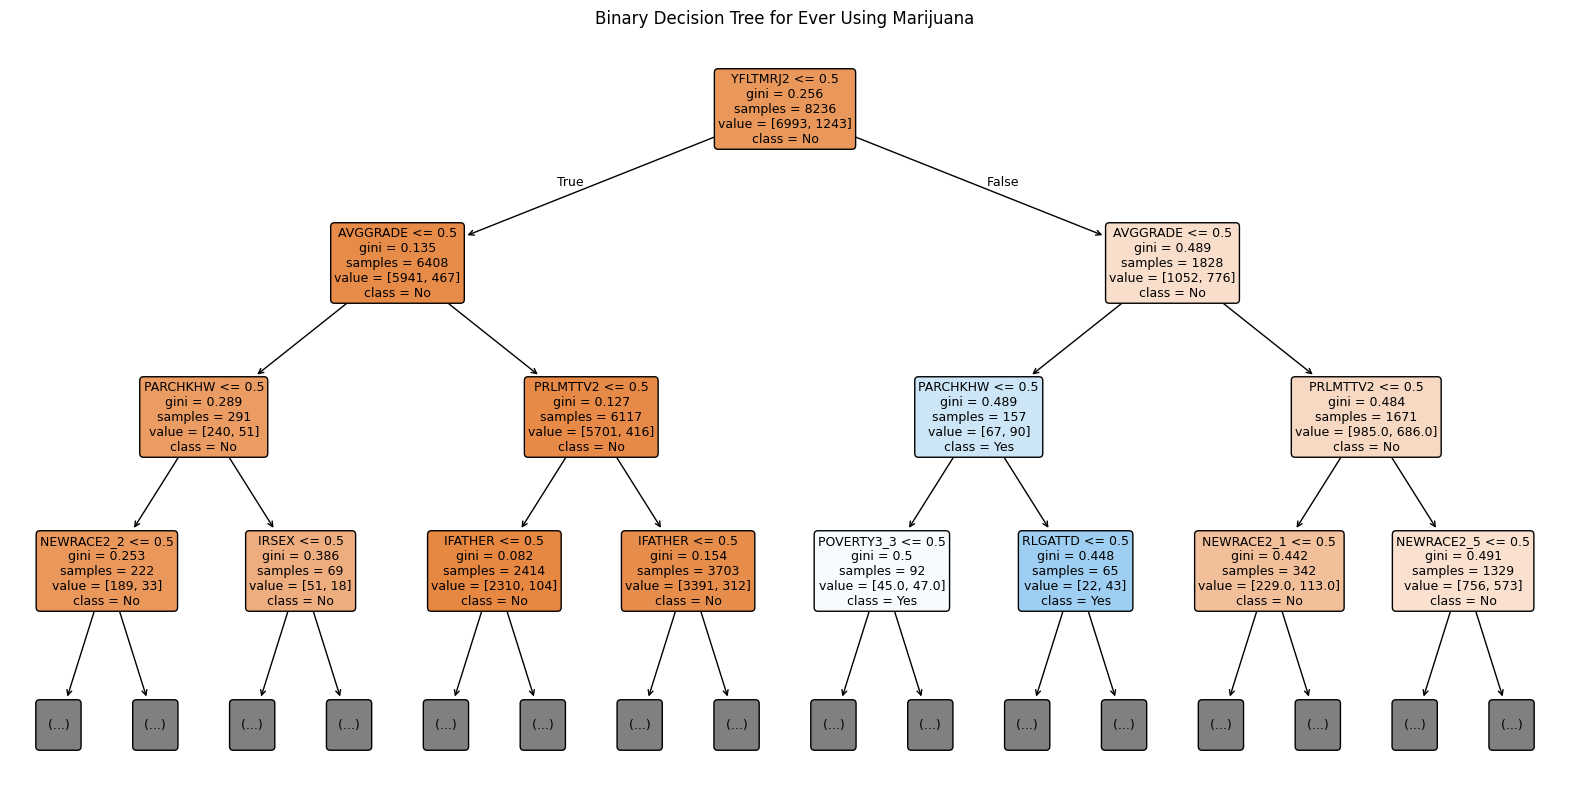

In [100]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_binary,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)

plt.title('Binary Decision Tree for Ever Using Marijuana (Top 3 Levels)')
plt.show()

The plot above shows the binary decision tree used to predict whether a youth ever used marijuana.

The first split is on YFLTMRJ2 <= 0.5, which measures how the youth feels about their peers trying marijuana. This path follows the left branch, which means ***. The second split is on AVGGRADE <= 0.5, which measures the youth's **. This path follows the left branch, which means *. The third split is on PARCHKHW <= 0.5, which measures how often the youth's parents check if they completed their homework.


In [94]:
importance_df_binary = pd.DataFrame({
    'Feature' :X_train_bin.columns,
    'Importance': best_binary_tree.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df_binary.head())

    Feature  Importance
5  YFLTMRJ2    0.448300
0   IFATHER    0.065700
1     IRSEX    0.054179
2  PRCHORE2    0.050720
6   RLGATTD    0.050194


In [95]:
importance_df_multi = pd.DataFrame({
    'Feature' :X_train_multi.columns,
    'Importance': best_multi_tree.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df_multi.head())

       Feature  Importance
5     YFLTMRJ2    0.919067
10  POVERTY3_3    0.080933
0      IFATHER    0.000000
16  NEWRACE2_6    0.000000
15  NEWRACE2_5    0.000000


In [96]:
importance_df_reg = pd.DataFrame({
    'Feature' :X_train_reg.columns,
    'Importance': best_reg_tree.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df_reg.head())

       Feature  Importance
0      IFATHER         0.0
1        IRSEX         0.0
16  NEWRACE2_6         0.0
15  NEWRACE2_5         0.0
14  NEWRACE2_4         0.0


## Discussion

For the regression classification baseline and pruned models, none of the features were found to be important.

For the multi-class classification pruned model, YFLTMRJ2 (how the youth feels about their peers trying marijuana) was the strongest predictor of ALCMDAYS (number of days the youth used alcohol in the past month).

For the binary classification pruned model, YFLTMRJ2 (how the youth feels about their peers trying marijuana) was also the strongest predictor but of IRCIGFM (cigarette usage frequency in the past month).

Class imbalance was an issue in both the binary classification and multi-class classification models.

Limitations are present. More careful consideration throughout this notebook needs to be done before further discussion can be confidently done.



## Conclusion

This notebook investigated how well youth demographics, family life, and experiences can predict alcohol, marijuana, and cigarette usage. Decision trees (binary classification, multi-class classification, and regression classification) were utilized to examine the predictors chosen in relation to the target variables chosen.